## **Background**

Retention rate is one of the customer behaviors that can be necessary things in evaluating business performance. Retention rate shows the measurement of customer loyalty to consume our product in a certain period. This project will analyze retention rate from one kind of retail store using cohort analysis.

Data Overview:
1. order_id : an unique code from every transaction.
2. product_code : an unique code from product
3. product_name : name of a product
4. quantity : number of goods ordered
5. order_date : datetime order created
6. price : price of a product
7. customer_id : an unique code from customer

In [354]:
import pandas as pd
import numpy as np 
import datetime as datetime
import seaborn as sns
import matplotlib.pyplot as plt
import re
import datetime as dt
from scipy import stats

In [355]:
# Import dataset
file= 'https://drive.google.com/file/d/1ELg9NNsaC44Q8r-Y7i8UKzUwZuNKFEom/view?usp=sharing'
url= 'https://drive.google.com/uc?id=' + file.split('/')[-2]
datar= pd.read_csv(url)
datar.head()

,order_id,product_code,product_name,quantity,order_date,price,customer_id
0,493410,TEST001,This is a test product.,5,2010-01-04 09:24:00,4.50,12346.0
1,C493411,21539,RETRO SPOTS BUTTER DISH,-1,2010-01-04 09:43:00,4.25,14590.0
2,493412,TEST001,This is a test product.,5,2010-01-04 09:53:00,4.50,12346.0
3,493413,21724,PANDA AND BUNNIES STICKER SHEET,1,2010-01-04 09:54:00,0.85,NaN
4,493413,84578,ELEPHANT TOY WITH BLUE T-SHIRT,1,2010-01-04 09:54:00,3.75,NaN


## **Data Understanding**

In [356]:
# Dataframe info
data= datar.copy()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 461773 entries, 0 to 461772
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   order_id      461773 non-null  object 
 1   product_code  461773 non-null  object 
 2   product_name  459055 non-null  object 
 3   quantity      461773 non-null  int64  
 4   order_date    461773 non-null  object 
 5   price         461773 non-null  float64
 6   customer_id   360853 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 24.7+ MB


In [357]:
data.isnull().sum()

order_id             0
product_code         0
product_name      2718
quantity             0
order_date           0
price                0
customer_id     100920
dtype: int64

In [358]:
# Order ID check

pop=[]
for i in data['order_id']:
    op=re.findall(r'\D',i)
    if op not in pop and op!=[]:
        pop.append(op)
print(pop)


[['C'], ['A']]


In [359]:
# Whats 'C' in order_id
(data[data['order_id'].str.contains('C')]).head()

,order_id,product_code,product_name,quantity,order_date,price,customer_id
1,C493411,21539,RETRO SPOTS BUTTER DISH,-1,2010-01-04 09:43:00,4.25,14590.0
12,C493415,21527,RETRO SPOT TRADITIONAL TEAPOT,-3,2010-01-04 10:33:00,7.95,14590.0
13,C493426,22109,FULL ENGLISH BREAKFAST PLATE,-1,2010-01-04 10:41:00,3.39,16550.0
56,C493430,21556,CERAMIC STRAWBERRY MONEY BOX,-1,2010-01-04 11:43:00,2.55,14680.0
57,C493430,21232,STRAWBERRY CERAMIC TRINKET BOX,-2,2010-01-04 11:43:00,1.25,14680.0


In [ ]:
# Product code check
pur=[]
for i in data['product_code']:
    op=re.findall(r'[A-Za-z]',i)
    if i not in pur and op!=[]:
        pur.append(i)
print(pur)

['TEST001', '35001G', '18096C', '72369A', '84563A', '84562A', '85123A', '84029E', '47591D', '85132B', '84032A', '84997A', '84997B', '84997C', '84997D', '15060B', '85099C', '85099B', '84520D', '84596F', '84596B', '84596E', '84559A', '84031B', '72800D', '72038P', '84031A', '16207A', '40046A', '84288B', '85231B', '85231L', '85049B', '84558A', '35004P', '35004G', '46776A', '46776B', '46776E', '46776C', '46776F', '72800C', '72799F', '72799C', '72799E', '72800F', '72800A', '72800B', '72799A', '85132A', '71028B', '85167B', '85166B', '85167A', '85183A', '85183B', '47347B', '84596K', '84596J', '84535A', '79190B', '79190A', '79190D', '85099F', '82001S', '84671B', '84741C', '85049F', '84029C', '84509F', '85232B', '46000M', '47566B', '79323W', '85129C', '85129D', '84845C', '84845D', '82494L', '17164D', '84292B', '85199L', '85185B', '85185F', '47578A', '84659A', '35096A', '35096B', '84970L', '85185C', '84510A', '40046C', '84753A', '84029D', '84671A', '90004A', '90121B', '35980C', '62097A', '84877C'

In [385]:
# Product_code check
(data[data['product_code']=='35609A']).head()   #Random letters on the last product code are also sellable products.

,order_id,product_code,product_name,quantity,order_date,price,customer_id
527,493536,35609A,PINK FEATHER CHRISTMAS DECORATION,24,2010-01-04 15:29:00,0.19,17841.0
706,493569,35609A,PINK FEATHER CHRISTMAS DECORATION,24,2010-01-05 09:29:00,0.19,13901.0
4874,494016,35609A,PINK FEATHER CHRISTMAS DECORATION,6,2010-01-11 09:35:00,2.57,NaN
84388,502444,35609A,PINK FEATHER CHRISTMAS DECORATION,2,2010-03-24 13:30:00,0.19,14729.0
137921,507929,35609A,NaN,-44,2010-05-12 10:08:00,0.00,NaN


In [ ]:
# How about the other

pup=[]
for i in data['product_code']:
    op=re.findall(r'^([A-Za-z])[A-Za-z]*\d*\D*+$',i)
    if i not in pup and op!=[]:
        pup.append(i)
print(pup)


['TEST001', 'POST', 'M', 'DOT', 'DCGS0058', 'BANK CHARGES', 'D', 'PADS', 'DCGS0068', 'DCGS0076', 'ADJUST', 'DCGSSGIRL', 'DCGS0006', 'DCGS0016', 'DCGS0027', 'DCGS0036', 'DCGS0039', 'DCGS0060', 'DCGS0056', 'DCGS0059', 'GIFT', 'DCGSLBOY', 'C2', 'm', 'DCGS0053', 'DCGS0004', 'DCGS0062', 'DCGS0037', 'DCGSSBOY', 'DCGSLGIRL', 'S', 'DCGS0069', 'DCGS0070', 'DCGS0075', 'B', 'DCGS0041', 'DCGS0003', 'ADJUST2', 'C3', 'SP1002', 'AMAZONFEE']


In [ ]:
# Product_code check
(data[data['product_code']=='DCGS0060'])    #Product_code that start with a letter and end with a numbers are clasified as unnecessary data

,order_id,product_code,product_name,quantity,order_date,price,customer_id
33026,496814,DCGS0060,NaN,-3,2010-02-04 09:46:00,0.0,NaN


In [362]:
(data[data['product_name'].str.lower().str.contains('adjust',na=False)]).head()

,order_id,product_code,product_name,quantity,order_date,price,customer_id
23816,C495737,ADJUST,Adjustment by john on 26/01/2010 16,-1,2010-01-26 16:23:00,10.50,16154.0
23817,C495740,ADJUST,Adjustment by john on 26/01/2010 16,-1,2010-01-26 16:24:00,14.00,13054.0
23818,C495739,ADJUST,Adjustment by john on 26/01/2010 16,-1,2010-01-26 16:24:00,10.50,15383.0
23819,C495741,ADJUST,Adjustment by john on 26/01/2010 16,-1,2010-01-26 16:25:00,13.14,16840.0
23863,C495751,ADJUST,Adjustment by john on 26/01/2010 16,-1,2010-01-26 16:28:00,26.19,12858.0


In [363]:
# Quantity Check
data[data['quantity']<0]

,order_id,product_code,product_name,quantity,order_date,price,customer_id
1,C493411,21539,RETRO SPOTS BUTTER DISH,-1,2010-01-04 09:43:00,4.25,14590.0
12,C493415,21527,RETRO SPOT TRADITIONAL TEAPOT,-3,2010-01-04 10:33:00,7.95,14590.0
13,C493426,22109,FULL ENGLISH BREAKFAST PLATE,-1,2010-01-04 10:41:00,3.39,16550.0
56,C493430,21556,CERAMIC STRAWBERRY MONEY BOX,-1,2010-01-04 11:43:00,2.55,14680.0
57,C493430,21232,STRAWBERRY CERAMIC TRINKET BOX,-2,2010-01-04 11:43:00,1.25,14680.0
...,...,...,...,...,...,...,...
460995,C539950,85099B,JUMBO BAG RED RETROSPOT,-10,2010-12-23 11:50:00,1.95,13534.0
460996,C539950,22720,SET OF 3 CAKE TINS PANTRY DESIGN,-2,2010-12-23 11:50:00,4.95,13534.0
461068,C539956,35004C,SET OF 3 COLOURED FLYING DUCKS,-15,2010-12-23 12:55:00,4.65,12980.0
461596,539980,35001W,NaN,-36,2010-12-23 14:34:00,0.00,NaN


In [364]:
# Price Check
data[data['price']<0]

,order_id,product_code,product_name,quantity,order_date,price,customer_id
124462,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN
213524,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN
329774,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN


**NOTE**
1. There are missing value from product_name and customer_id columns.
2. There are some inappropriate data type.
3. There are unique codes from order_id colomns. order_id starts with 'C' will be clasifeid as canceled order and 'A' will be clasdified as Adjustment.
4. There are some unnecessary product code and we assume there aren't transsaction goods from cust, so will be drop soon.
5. Most of a negative values from quantity columns are canceled order or Missing value from product_name.
6. Negative values from price are adjustment product.

## **Data Cleansing**

In [365]:
# Drop All missing value
datac=data.copy()
datac= datac.dropna()
datac.info()

<class 'pandas.core.frame.DataFrame'>
Index: 360853 entries, 0 to 461744
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   order_id      360853 non-null  object 
 1   product_code  360853 non-null  object 
 2   product_name  360853 non-null  object 
 3   quantity      360853 non-null  int64  
 4   order_date    360853 non-null  object 
 5   price         360853 non-null  float64
 6   customer_id   360853 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 22.0+ MB


In [366]:
# Check Unnecessary value after Dropna

puc=[]
for i in datac['product_code']:
    op=re.findall(r'^([A-Za-z])[A-Za-z]*\d*\D*+$',i)
    if i not in puc and op!=[]:
        puc.append(i)
print(puc)


['TEST001', 'POST', 'M', 'D', 'PADS', 'ADJUST', 'C2', 'BANK CHARGES', 'ADJUST2', 'SP1002']


In [367]:
# Drop All Unnecesssary values
seperate='|'
pilter= seperate.join(puc)
pilter

datac= datac[~(datac['product_code'].str.contains(pilter,case=False) |
             datac['order_id'].str.lower().str.contains('c|a', case=False))]
datac

,order_id,product_code,product_name,quantity,order_date,price,customer_id
6,493414,21844,RETRO SPOT MUG,36,2010-01-04 10:28:00,2.55,14590.0
7,493414,21533,RETRO SPOT LARGE MILK JUG,12,2010-01-04 10:28:00,4.25,14590.0
8,493414,37508,NEW ENGLAND CERAMIC CAKE SERVER,2,2010-01-04 10:28:00,2.55,14590.0
9,493414,35001G,HAND OPEN SHAPE GOLD,2,2010-01-04 10:28:00,4.25,14590.0
10,493414,21527,RETRO SPOT TRADITIONAL TEAPOT,12,2010-01-04 10:28:00,6.95,14590.0
...,...,...,...,...,...,...,...
461739,539988,84378,SET OF 3 HEART COOKIE CUTTERS,1,2010-12-23 16:06:00,1.25,18116.0
461740,539988,84380,SET OF 3 BUTTERFLY COOKIE CUTTERS,1,2010-12-23 16:06:00,1.25,18116.0
461742,539988,84849B,FAIRY SOAP SOAP HOLDER,1,2010-12-23 16:06:00,1.69,18116.0
461743,539988,22854,CREAM SWEETHEART EGG HOLDER,2,2010-12-23 16:06:00,4.95,18116.0


In [368]:
# Check Again Unnecessary value

puc=[]
for i in datac['product_code']:
    op=re.findall(r'^([A-Za-z])[A-Za-z]*\d*\D*+$',i)
    if i not in puc and op!=[]:
        puc.append(i)
print(puc)


[]


In [369]:
# Change data type
datac['order_date']= pd.to_datetime(datac['order_date'])
datac['customer_id']= datac['customer_id'].astype(str)

datac.head()

,order_id,product_code,product_name,quantity,order_date,price,customer_id
6,493414,21844,RETRO SPOT MUG,36,2010-01-04 10:28:00,2.55,14590.0
7,493414,21533,RETRO SPOT LARGE MILK JUG,12,2010-01-04 10:28:00,4.25,14590.0
8,493414,37508,NEW ENGLAND CERAMIC CAKE SERVER,2,2010-01-04 10:28:00,2.55,14590.0
9,493414,35001G,HAND OPEN SHAPE GOLD,2,2010-01-04 10:28:00,4.25,14590.0
10,493414,21527,RETRO SPOT TRADITIONAL TEAPOT,12,2010-01-04 10:28:00,6.95,14590.0


In [370]:
# Outlier handling
score= stats.zscore(datac[['quantity','price']])
score.max()

np.float64(149.20937173330466)

In [371]:
parjo= datac[(score>100).any(axis=1)]
parjo

,order_id,product_code,product_name,quantity,order_date,price,customer_id
83302,502269,21984,PACK OF 12 PINK PAISLEY TISSUES,10000,2010-03-23 15:36:00,0.25,17940.0
83303,502269,21982,PACK OF 12 SUKI TISSUES,10000,2010-03-23 15:36:00,0.25,17940.0
83304,502269,21980,PACK OF 12 RED SPOTTY TISSUES,10000,2010-03-23 15:36:00,0.25,17940.0
83305,502269,21981,PACK OF 12 WOODLAND TISSUES,10000,2010-03-23 15:36:00,0.25,17940.0
260032,521315,17003,BROCADE RING PURSE,7128,2010-09-03 12:01:00,0.19,15838.0
288863,524174,21096,SET/6 FRUIT SALAD PAPER PLATES,7008,2010-09-27 16:30:00,0.13,13687.0
288864,524174,21088,SET/6 FRUIT SALAD PAPER CUPS,7128,2010-09-27 16:30:00,0.08,13687.0
355872,530715,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,9360,2010-11-04 11:36:00,1.69,15838.0


We decided to include outlier data for cohort analysis because we assumed they are a part of cust transaction also. The outlier happens because a huge quantity of ordered by cust.

In [372]:
# Check
datac.info()

<class 'pandas.core.frame.DataFrame'>
Index: 348680 entries, 6 to 461744
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   order_id      348680 non-null  object        
 1   product_code  348680 non-null  object        
 2   product_name  348680 non-null  object        
 3   quantity      348680 non-null  int64         
 4   order_date    348680 non-null  datetime64[ns]
 5   price         348680 non-null  float64       
 6   customer_id   348680 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 21.3+ MB


In [373]:
datac.describe()

,quantity,order_date,price
count,348680.000000,348680,348680.000000
mean,11.969502,2010-07-22 18:05:28.569002752,3.001501
min,1.000000,2010-01-04 10:28:00,0.000000
25%,2.000000,2010-04-25 13:20:00,1.250000
50%,4.000000,2010-08-03 14:23:00,1.950000
75%,12.000000,2010-10-25 11:33:00,3.750000
max,10000.000000,2010-12-23 16:06:00,295.000000
std,66.939795,NaN,4.490323


## **Analysis**

In [374]:
# Convert datetime to periode of month (cohort)
datac['cohort']= datac['order_date'].dt.to_period('M')
datac.head()

,order_id,product_code,product_name,quantity,order_date,price,customer_id,cohort
6,493414,21844,RETRO SPOT MUG,36,2010-01-04 10:28:00,2.55,14590.0,2010-01
7,493414,21533,RETRO SPOT LARGE MILK JUG,12,2010-01-04 10:28:00,4.25,14590.0,2010-01
8,493414,37508,NEW ENGLAND CERAMIC CAKE SERVER,2,2010-01-04 10:28:00,2.55,14590.0,2010-01
9,493414,35001G,HAND OPEN SHAPE GOLD,2,2010-01-04 10:28:00,4.25,14590.0,2010-01
10,493414,21527,RETRO SPOT TRADITIONAL TEAPOT,12,2010-01-04 10:28:00,6.95,14590.0,2010-01


In [375]:
# Search first cohort
first= datac.groupby('customer_id')['cohort'].min().reset_index()
first.columns=['customer_id','first_cohort']
datac= datac.merge(first, on='customer_id', how='left')
datac.head()

,order_id,product_code,product_name,quantity,order_date,price,customer_id,cohort,first_cohort
0,493414,21844,RETRO SPOT MUG,36,2010-01-04 10:28:00,2.55,14590.0,2010-01,2010-01
1,493414,21533,RETRO SPOT LARGE MILK JUG,12,2010-01-04 10:28:00,4.25,14590.0,2010-01,2010-01
2,493414,37508,NEW ENGLAND CERAMIC CAKE SERVER,2,2010-01-04 10:28:00,2.55,14590.0,2010-01,2010-01
3,493414,35001G,HAND OPEN SHAPE GOLD,2,2010-01-04 10:28:00,4.25,14590.0,2010-01,2010-01
4,493414,21527,RETRO SPOT TRADITIONAL TEAPOT,12,2010-01-04 10:28:00,6.95,14590.0,2010-01,2010-01


In [376]:
# Search cohort distance
from operator import attrgetter

datac['cohort_distance']= (datac['cohort']-datac['first_cohort']).apply(attrgetter('n'))+1
datac.head()

,order_id,product_code,product_name,quantity,order_date,price,customer_id,cohort,first_cohort,cohort_distance
0,493414,21844,RETRO SPOT MUG,36,2010-01-04 10:28:00,2.55,14590.0,2010-01,2010-01,1
1,493414,21533,RETRO SPOT LARGE MILK JUG,12,2010-01-04 10:28:00,4.25,14590.0,2010-01,2010-01,1
2,493414,37508,NEW ENGLAND CERAMIC CAKE SERVER,2,2010-01-04 10:28:00,2.55,14590.0,2010-01,2010-01,1
3,493414,35001G,HAND OPEN SHAPE GOLD,2,2010-01-04 10:28:00,4.25,14590.0,2010-01,2010-01,1
4,493414,21527,RETRO SPOT TRADITIONAL TEAPOT,12,2010-01-04 10:28:00,6.95,14590.0,2010-01,2010-01,1


In [377]:
# Create Pivot summary of data

pvt= pd.pivot_table(data=datac, index='first_cohort', columns='cohort_distance',
                     values='customer_id', aggfunc=pd.Series.nunique)
pvt_cohort = pvt.div(pvt[1], axis=0)
pvt_cohort

cohort_distance,1,2,3,4,5,6,7,8,9,10,11,12
first_cohort,,,,,,,,,,,,
2010-01,1.0,0.366972,0.477064,0.443425,0.397554,0.432722,0.400612,0.383792,0.385321,0.438838,0.474006,0.356269
2010-02,1.0,0.284501,0.271762,0.337580,0.305732,0.261146,0.237792,0.352442,0.324841,0.348195,0.210191,NaN
2010-03,1.0,0.231776,0.259813,0.271028,0.241121,0.229907,0.272897,0.349533,0.342056,0.171963,NaN,NaN
2010-04,1.0,0.198171,0.216463,0.192073,0.198171,0.225610,0.298780,0.301829,0.146341,NaN,NaN,NaN
2010-05,1.0,0.179856,0.190647,0.179856,0.179856,0.258993,0.244604,0.154676,NaN,NaN,NaN,NaN
2010-06,1.0,0.163569,0.193309,0.219331,0.241636,0.304833,0.137546,NaN,NaN,NaN,NaN,NaN
2010-07,1.0,0.161111,0.183333,0.283333,0.283333,0.155556,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,1.0,0.192771,0.283133,0.307229,0.156627,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-09,1.0,0.240175,0.240175,0.131004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [390]:
# cohort size

pvt_size= pvt.loc[:,1].reset_index()
# size= pd.DataFrame(pvt_size)
pvt_size.columns=['first_cohort','cohort_size']
pvt_size['first_cohort']= pvt_size['first_cohort'].dt.strftime('%b %Y')
pvt_size['cohort_size']= pvt_size['cohort_size'].astype(int)
pvt_size= pvt_size.set_index('first_cohort')
pvt_size

,cohort_size
first_cohort,
Jan 2010,654
Feb 2010,471
Mar 2010,535
Apr 2010,328
May 2010,278
Jun 2010,269
Jul 2010,180
Aug 2010,166
Sep 2010,229


## **Result**

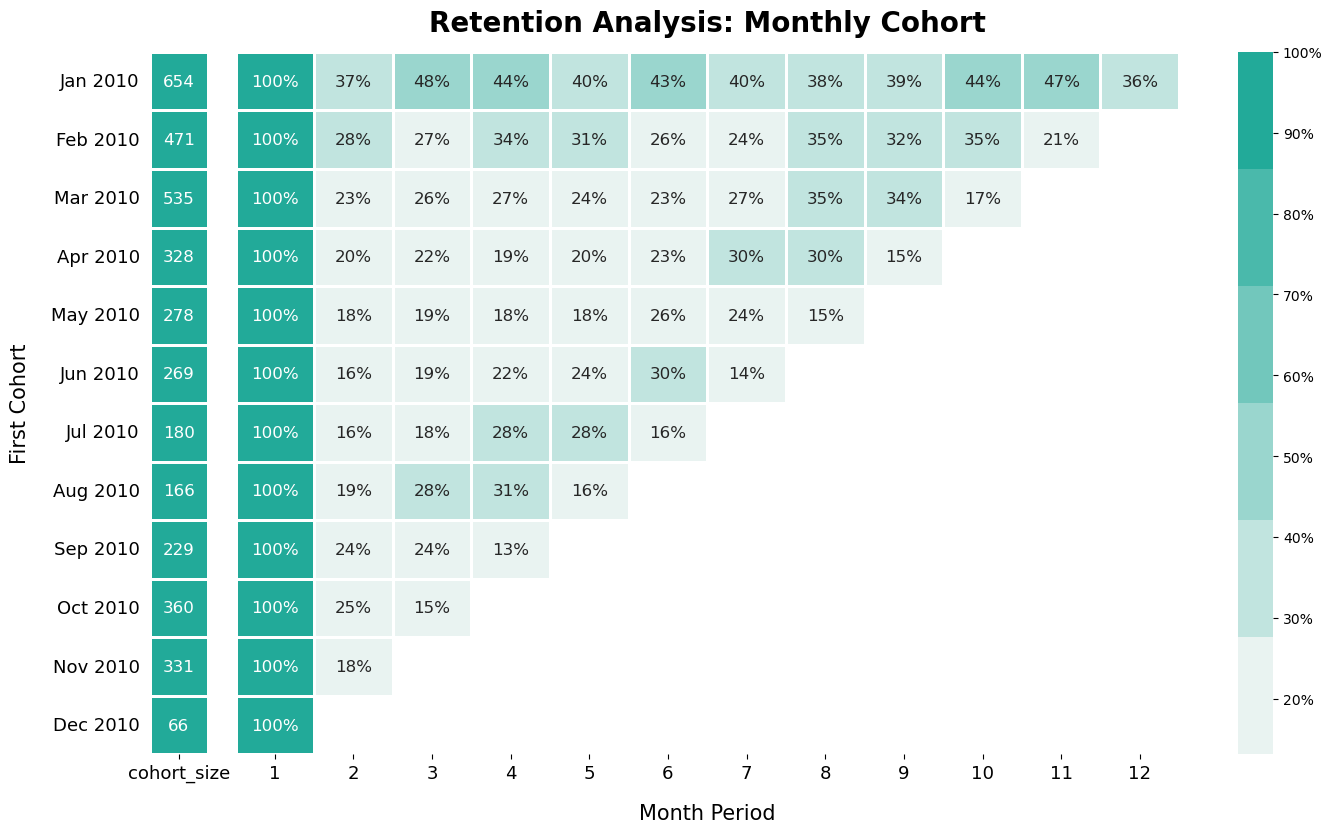

In [379]:
# Create Cohort Matrix
from matplotlib.colors import ListedColormap

fig, ax= plt.subplots(1, 2, figsize=(14,8), gridspec_kw={'width_ratios':[1,11]}, sharey='row')

sns.heatmap(pvt_cohort, annot=True, annot_kws={'size':12}, fmt='.0%', ax=ax[1],
            linewidths=2, cmap=sns.color_palette("light:#2A9"), cbar_kws={'format':'{x:.0%}'})
ax[1].tick_params(left=False)
ax[1].set_ylabel("")
ax[1].set_xlabel('Month Period', labelpad=15, size=15)
ax[1].tick_params(axis='x', labelsize=13)


co="#2A9"
cmap = ListedColormap([co])
sns.heatmap(pvt_size, annot=True, annot_kws={'size':12}, fmt=',', ax=ax[0], cbar=False, linewidths=2,
            linecolor="#FFFFFF", square=True, cmap=cmap)
ax[0].set_ylabel('First Cohort', labelpad=15, size=15)
ax[0].tick_params(axis='both', labelsize=13, left=False )

plt.title('Retention Analysis: Monthly Cohort', fontweight='bold', fontsize=20, pad=15)
plt.tight_layout(pad=-0.5)
plt.show()